In [1]:
from google.colab import files
uploaded = files.upload()

Saving crop_data.csv to crop_data.csv


In [2]:
import pandas as pd

data = pd.read_csv("crop_data.csv")

In [3]:
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
data.shape

(2200, 8)

In [7]:
clean_data=data.copy()

In [8]:
clean_data.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [9]:
clean_data=clean_data.drop_duplicates()

In [10]:
clean_data.columns=clean_data.columns.str.strip().str.lower()

In [11]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   n            2200 non-null   int64  
 1   p            2200 non-null   int64  
 2   k            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [12]:
clean_data.to_csv("cleaned_crop_data.csv", index=False)

In [13]:
files.download("cleaned_crop_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data=pd.read_csv("cleaned_crop_data.csv")

**the crops appers most**

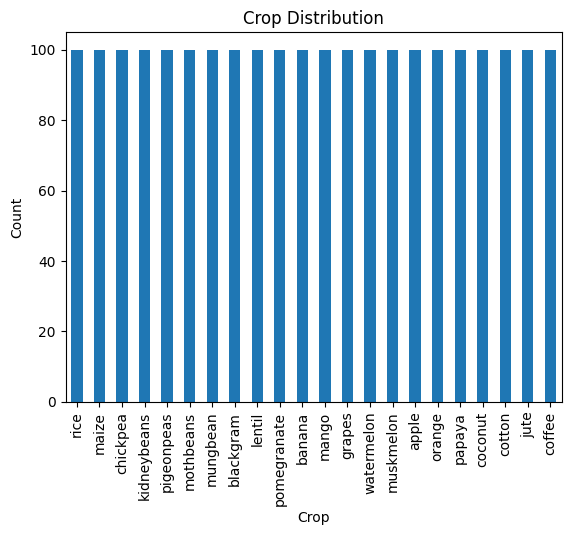

In [15]:
plt.figure()
data["label"].value_counts().plot(kind="bar")
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

**Climate condition affect crops**

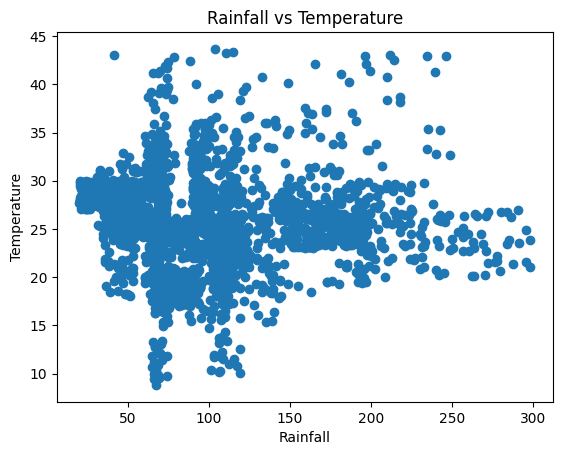

In [16]:
plt.figure()
plt.scatter(data["rainfall"], data["temperature"])
plt.xlabel("Rainfall")
plt.ylabel("Temperature")
plt.title("Rainfall vs Temperature")
plt.show()

**NPK Analysis**

<Figure size 640x480 with 0 Axes>

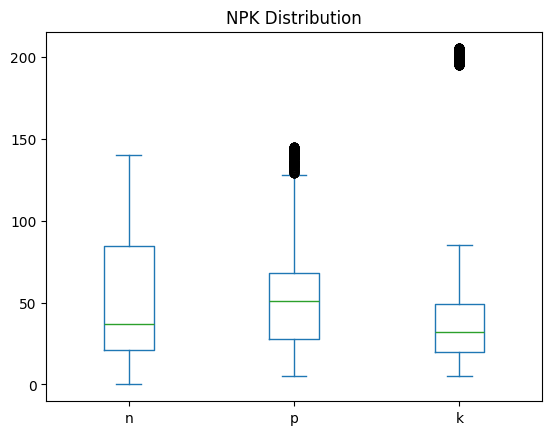

In [17]:
plt.figure()
data[["n","p","k"]].plot(kind="box")
plt.title("NPK Distribution")
plt.show()

**pH Distribution**

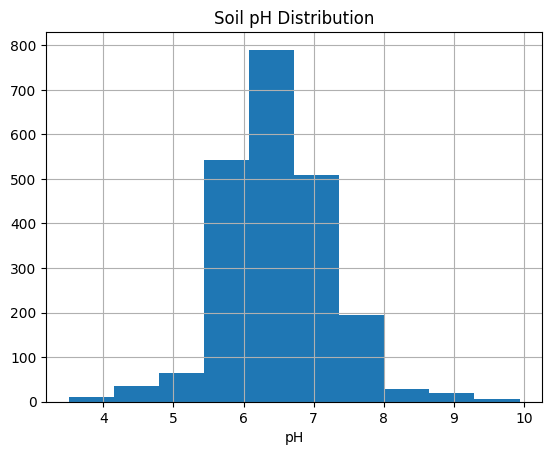

In [18]:
plt.figure()
data["ph"].hist()
plt.title("Soil pH Distribution")
plt.xlabel("pH")
plt.show()

**Related Factors**

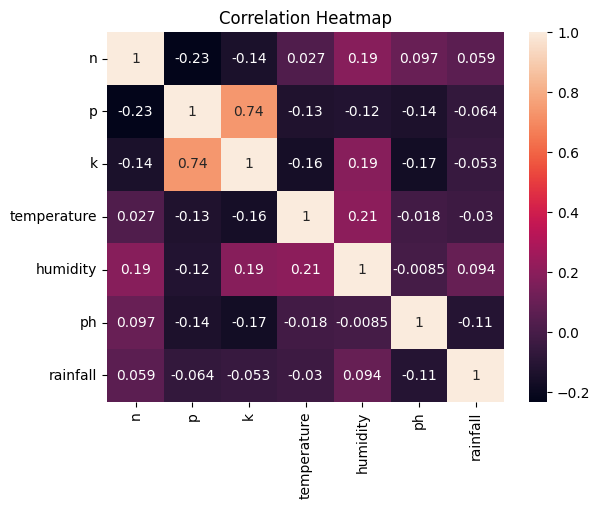

In [20]:
plt.figure()

numeric_data = data.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_data.corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
def recommend_crop(n, p, k, temp, humidity, ph, rainfall):

    filtered = data[
        (abs(data["n"] - n) <= 5) &
        (abs(data["p"] - p) <= 5) &
        (abs(data["k"] - k) <= 5) &
        (abs(data["temperature"] - temp) <= 3) &
        (abs(data["humidity"] - humidity) <= 10) &
        (abs(data["ph"] - ph) <= 1) &
        (abs(data["rainfall"] - rainfall) <= 20)
    ]

    if not filtered.empty:
        return filtered["label"].mode()[0]
    else:
        return "No suitable crop found"

In [22]:
recommend_crop(90, 40, 40, 25, 80, 6.5, 200)

'jute'

In [23]:
filtered = data[
    (abs(data["n"] - 90) <= 5) &
    (abs(data["p"] - 40) <= 5) &
    (abs(data["k"] - 40) <= 5) &
    (abs(data["temperature"] - 25) <= 3) &
    (abs(data["humidity"] - 80) <= 10) &
    (abs(data["ph"] - 6.5) <= 1) &
    (abs(data["rainfall"] - 200) <= 20)
]

filtered["label"].value_counts()

,count
label,
jute,7
rice,3
